# Task 4: US Accidents Data Analysis

## Objective

The objective of this task is to analyze the US Accidents dataset to identify accident trends, accident hotspots, weather conditions affecting accidents, and time-based patterns using Exploratory Data Analysis (EDA).

Shape: (100000, 46)

Columns:
Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   ----- 

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,100000.000000,100000.000000,100000.000000,0.0,0.0,100000.000000,98409.000000,4322.000000,98144.000000,98708.000000,98154.000000,76180.000000,7368.000000
mean,2.448120,35.630369,-119.322756,NaN,NaN,0.011345,66.641262,48.845812,59.794170,29.961021,9.338639,8.044165,0.025786
std,0.499931,2.101259,3.663525,NaN,NaN,0.262244,12.703846,19.898270,23.184442,0.275672,1.885828,4.298926,0.051695
min,1.000000,32.542587,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,2.980000,0.100000,0.000000,0.000000
25%,2.000000,33.957775,-121.828468,NaN,NaN,0.000000,57.900000,37.100000,43.000000,29.890000,10.000000,4.600000,0.000000
50%,2.000000,34.168579,-118.384232,NaN,NaN,0.000000,66.000000,42.500000,62.000000,29.970000,10.000000,6.900000,0.000000
75%,3.000000,37.776682,-117.916023,NaN,NaN,0.010000,75.000000,63.000000,78.000000,30.060000,10.000000,10.400000,0.030000
max,4.000000,41.428753,-81.550728,NaN,NaN,51.130000,114.100000,107.000000,100.000000,33.040000,80.000000,241.700000,0.550000


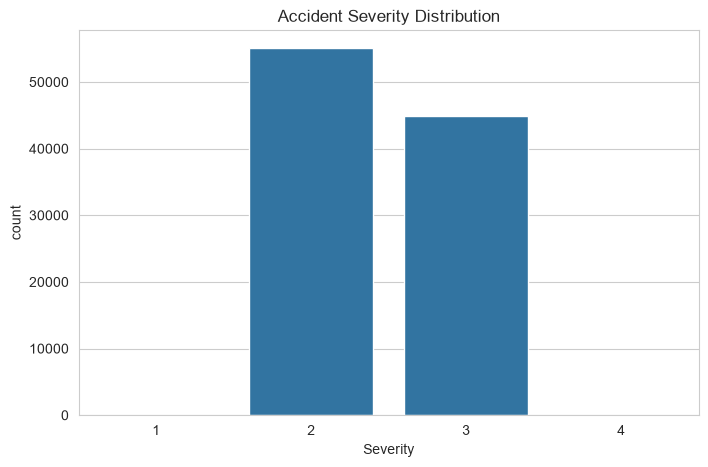

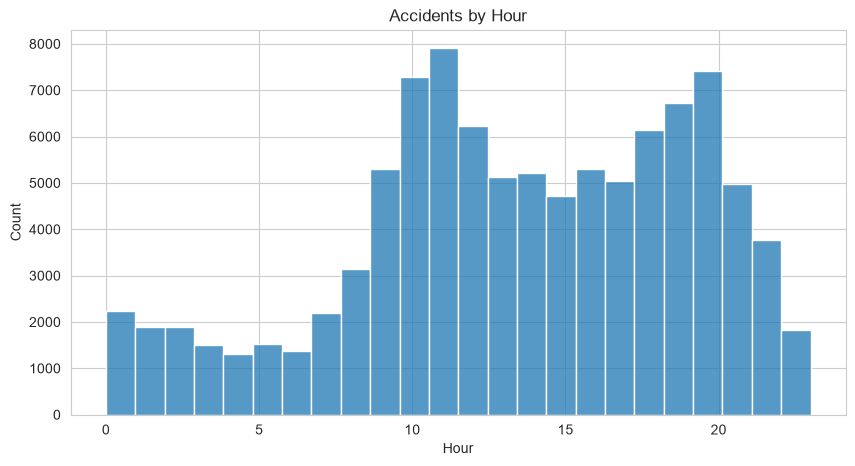

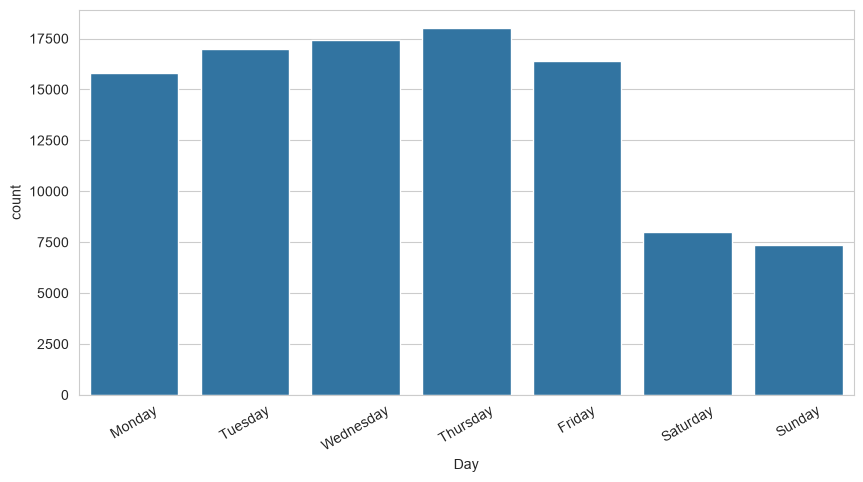

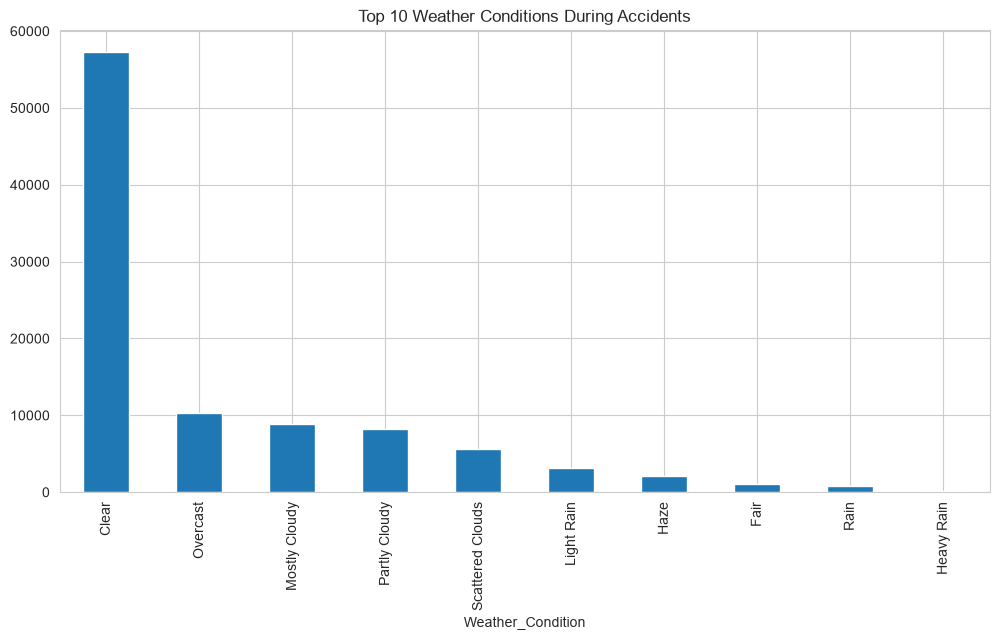

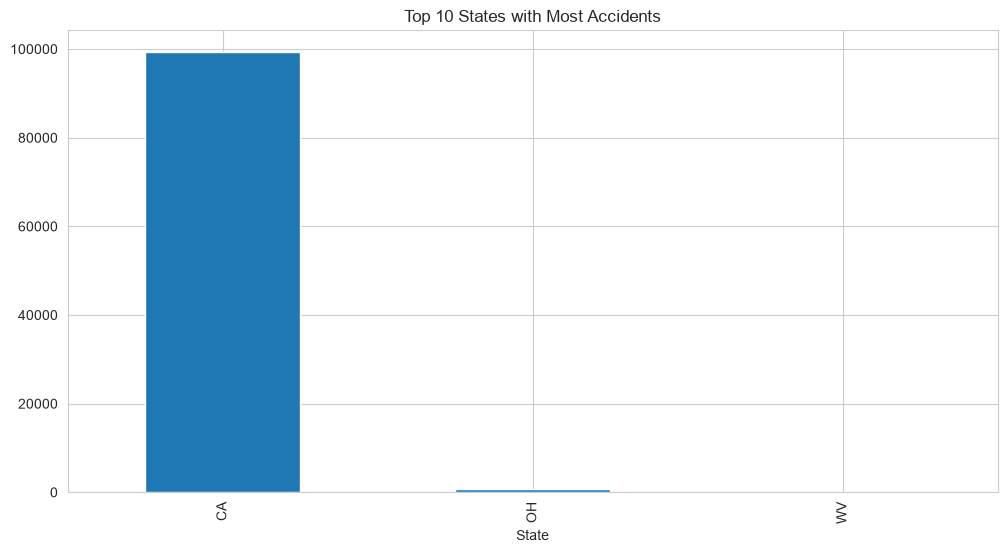

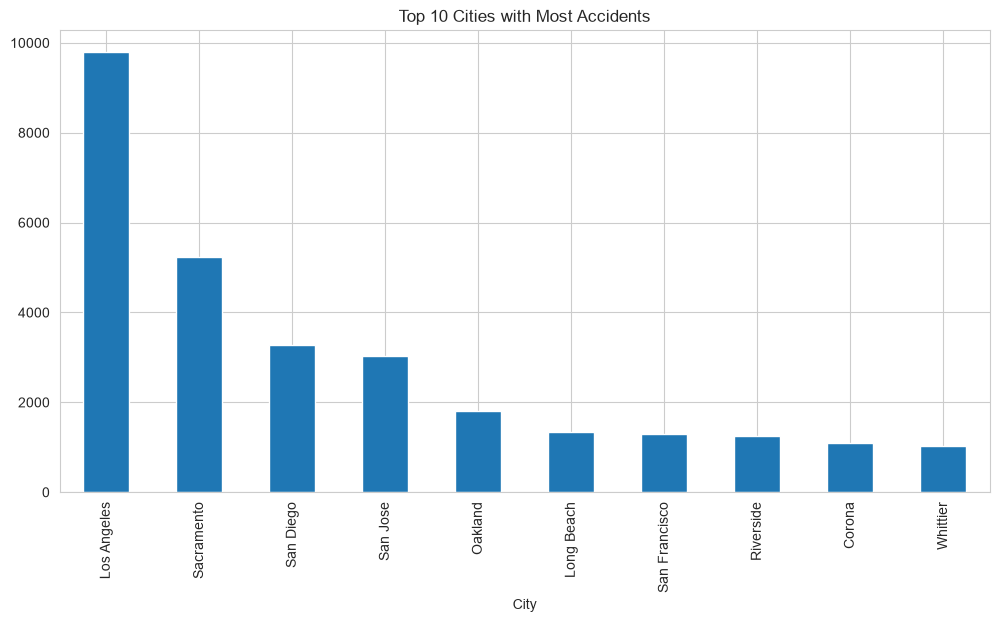

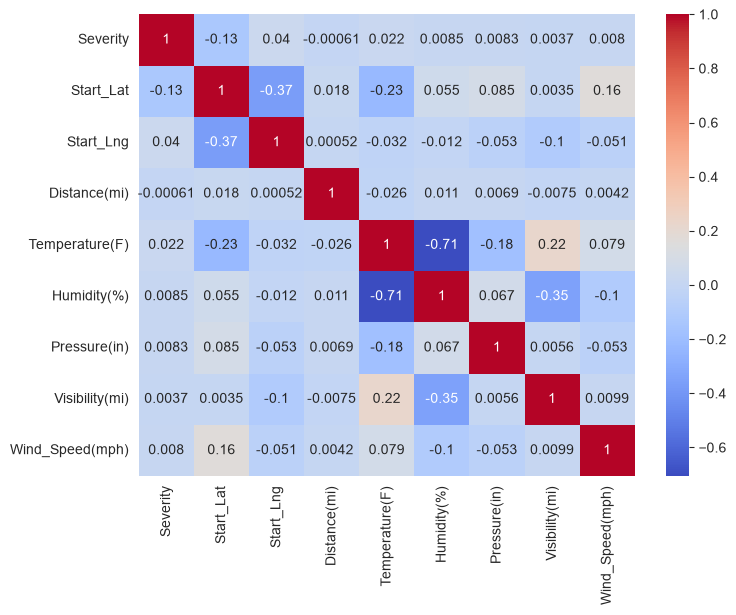

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

df = pd.read_csv("../datasets/US_Accidents_March23.csv", nrows=100000)
df.head()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInformation:")
df.info()
print("\nStatistical Summary:")
display(df.describe())

missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

numeric_columns = df.select_dtypes(include=["float64","int64"]).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

plt.figure(figsize=(8,5))
sns.countplot(x="Severity", data=df)
plt.title("Accident Severity Distribution")
plt.show()

df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["Hour"] = df["Start_Time"].dt.hour
plt.figure(figsize=(10,5))
sns.histplot(df["Hour"], bins=24)
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.show()

df["Day"] = df["Start_Time"].dt.day_name()
plt.figure(figsize=(10,5))
sns.countplot(
    x="Day",
    data=df,
    order=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]
)
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(12,6))
df["Weather_Condition"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Weather Conditions During Accidents")
plt.show()

plt.figure(figsize=(12,6))
df["State"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States with Most Accidents")
plt.show()

plt.figure(figsize=(12,6))
df["City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities with Most Accidents")
plt.show()

plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=["float64","int64"])
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True
)
plt.show()

# Key Insights

1. Most accidents were of moderate severity.
2. Accident frequency was higher during peak commuting hours.
3. Certain states and cities experienced significantly more accidents.
4. Clear weather and rain were among the most common weather conditions during accidents.
5. Some numerical features showed moderate correlations with accident severity.

# Conclusion

The US Accidents dataset was successfully analyzed using Exploratory Data Analysis techniques.
Missing values were handled, major accident hotspots were identified, accident trends across hours and days were analyzed, and weather conditions affecting accidents were explored.
These insights can help transportation authorities understand accident patterns and improve road safety planning.